一、模糊回归：X_reg.
二、X_eval:所有指标

In [1]:
import pandas as pd
import numpy as np
import sys
import os
from sklearn.linear_model import LinearRegression

project_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_path)
from models.mohu_model import IterativeMohuDecision
from models.model_validation import validate_fuzzy_model,plot_conf_grid_search,compare_conf_effect
from models.entropy_fce import fit_conf_with_grid_search
from models.decision_engine import DecisionEngine


In [2]:
# #重新加载mohu_model.py
# %reload_ext autoreload
# %autoreload 2
# %matplotlib inline

In [3]:
df = pd.read_excel('../data/city_data.xlsx')
df = df[df['year'] == 2023]
X = df.drop(columns=['city', 'year', 'inno']).values
y = df['inno'].values
city_names = df["city"].tolist()

In [4]:
#标准化
X_mean,X_std = X.mean(axis=0),X.std(axis=0)
y_mean, y_std = y.mean(), y.std()

X = (X - X_mean) / X_std
y = (y - y_mean) / y_std

In [5]:
X_reg = X.copy()
X_eval = X.copy()

In [6]:
# indicator_type = auto_indicator_type(X.shape[1]) 
# print("Indicator types:", indicator_type)
indicator_type = [1,1,1,1,1,1,1,-1,-1,1,1,1,1,1,1,1,1,1]#由用户输入indicator_type的值。

In [7]:
# 初始化决策引擎
engine = DecisionEngine(
    regression_config={
        "n": X_reg.shape[1],
        "number": X_reg.shape[0],
        "max_iter": 50
    },
    indicator_type=indicator_type
)

In [8]:
#重新加载mohu_model.py
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [9]:
result = engine.full_decision(
    X_eval=X_eval,
    X_reg=X_reg,
    y_reg=y,
    city_names=city_names,
    conf_mode='discrete'
)



========== 开始网格搜索（conf_conflict） ==========

[Conf调节] 权重调整效果:
  原始权重: [0.05602597 0.03013683 0.03700358 0.03116917 0.06650032]...
  调整后权重: [0.08301903 0.04465662 0.05483175 0.00461863 0.00985399]...

conf_conflict = 0.1
  Spearman = 0.8516
  STD      = 0.0954
  CV       = 0.2470
  Range    = 0.2989

[Conf调节] 权重调整效果:
  原始权重: [0.05602597 0.03013683 0.03700358 0.03116917 0.06650032]...
  调整后权重: [0.07880061 0.0423875  0.0520456  0.0087679  0.01870656]...

conf_conflict = 0.2
  Spearman = 0.8736
  STD      = 0.0870
  CV       = 0.2195
  Range    = 0.2759

[Conf调节] 权重调整效果:
  原始权重: [0.05602597 0.03013683 0.03700358 0.03116917 0.06650032]...
  调整后权重: [0.07499016 0.04033782 0.0495289  0.01251588 0.02670299]...

conf_conflict = 0.3
  Spearman = 0.9011
  STD      = 0.0799
  CV       = 0.1971
  Range    = 0.2552

[Conf调节] 权重调整效果:
  原始权重: [0.05602597 0.03013683 0.03700358 0.03116917 0.06650032]...
  调整后权重: [0.07153122 0.03847723 0.04724437 0.01591811 0.03396174]...

conf_conflict = 0.4
  Spearman 

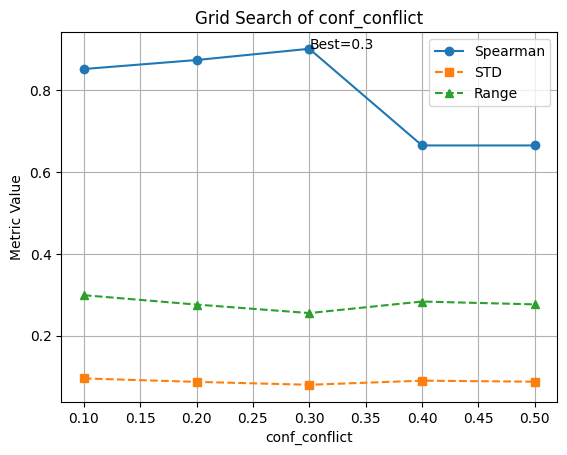

In [10]:
#网格搜索的图
plot_conf_grid_search(result["grid_results"])

In [11]:
print("模糊回归系数：")
print(result["regression_coef"]) 

模糊回归系数：
[ 3.75447870e-16  2.00624238e-01  3.09679557e-01  1.02901157e-01
 -2.92054908e-01 -2.89240472e-01  2.86003616e-01  2.23055977e-02
  1.50239767e-01 -1.43898017e-01  2.36524211e-02 -1.26793612e-01
 -1.07898698e-01 -6.77375990e-02  4.25783815e-01  6.09587068e-01
  5.24888977e-01 -2.11596103e-02 -1.95834274e-01]


In [12]:
print("语义置信度：")
print(result["semantic_confidence"])
# """语义置信度是用来控制对模糊规则的信任程度的指标，值越高表示对模糊规则的信任越强。
# 只会影响模糊综合评判的隶属度合成、最终等级、排序的稳定性、指标解释的可信程度
# 原本综合隶属度向量：B = W ⊗ R                 现在：B = (W × confidence) ⊗ R
# 不影响预测值（模糊回归）。"""

语义置信度：
[1.  1.  1.  0.3 0.3 1.  1.  0.3 1.  1.  0.3 0.3 0.3 1.  1.  1.  0.3 0.3]


In [13]:
print("熵权：")
print(result["weights"])
print("sum的值为",result["weights"].sum())  # sum必须等于 1
#熵权决定了谁重要，置信度决定了是否应该相信这个重要程度。

熵权：
[0.05602597 0.03013683 0.03700358 0.03116917 0.06650032 0.05226132
 0.06259058 0.03515054 0.0366781  0.07025374 0.04742927 0.02847929
 0.0383556  0.12068943 0.08239677 0.09069359 0.10071069 0.01347521]
sum的值为 1.0000000000000002


In [14]:
for i, r in enumerate(result["evaluation"]):
    # print(f"样本 {i}:")
    # print("  等级:", r["grade"])
    # print("  得分:", r["score"])
    print(f"{city_names[i]}得分：{r['score']:.4f}")
    # print(f"{city_names[i]}得分：{r['score']:.4f}。。。反标准化得分:{r['score'] * y_std + y_mean}")  #反标准化得分
    print("  隶属度:", r["membership"])


北京得分：0.5695
  隶属度: [0.18137193 0.19486436 0.19095857 0.13653364 0.27722642]
上海得分：0.5519
  隶属度: [0.17111274 0.31987911 0.09862302 0.0995023  0.29944706]
南京得分：0.3362
  隶属度: [0.35535581 0.27528187 0.12084981 0.08910492 0.07563076]
苏州得分：0.3916
  隶属度: [0.28978576 0.3740105  0.14913769 0.10038542 0.08126971]
杭州得分：0.4189
  隶属度: [0.16997466 0.38915893 0.30504984 0.12529524 0.01052134]
宁波得分：0.3385
  隶属度: [0.41583017 0.31705882 0.09830692 0.12888898 0.03991511]
合肥得分：0.3873
  隶属度: [0.26398549 0.07516806 0.09242921 0.07294026 0.22914319]
武汉得分：0.3824
  隶属度: [0.30505337 0.42828743 0.08332184 0.07308534 0.11025201]
长沙得分：0.3143
  隶属度: [0.43245163 0.19573679 0.08324332 0.07372078 0.10456029]
广州得分：0.4120
  隶属度: [0.1998006  0.34077969 0.27625412 0.1204819  0.03598069]
深圳得分：0.4884
  隶属度: [0.12111816 0.16744304 0.23052243 0.1395705  0.18688211]
重庆得分：0.3294
  隶属度: [0.32604902 0.26521141 0.10841572 0.01115648 0.14227979]
成都得分：0.3500
  隶属度: [0.25835814 0.19685464 0.13804812 0.20818857 0.02289443]


验证模糊回归模型

In [15]:
import pandas as pd
import numpy as np
import sys
import os
from sklearn.linear_model import LinearRegression

project_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_path)
from models.model_validation import validate_fuzzy_model


In [16]:
df_full = pd.read_excel('../data/city_data.xlsx')
y_full = df_full["inno"].values
X_full = df_full.drop(columns=["year", "city", "inno"]).values

# 对所有年份的数据进行标准化 (与 mohu_data.ipynb 保持一致)
X_full_mean, X_full_std = X_full.mean(axis=0), X_full.std(axis=0)
y_full_mean, y_full_std = y_full.mean(), y_full.std()

X_full_scaled = (X_full - X_full_mean) / X_full_std
y_full_scaled = (y_full - y_full_mean) / y_full_std

In [17]:
# 2. 获取已训练的模糊回归模型
# X_reg 和 y_reg 是上面的 X_full_scaled 和 y_full_scaled
fuzzy_model_trained = engine.regression

#创建标准的 OLS 模型用于对比
ols_model = LinearRegression()

In [18]:
#3. 执行验证 
from models.model_validation import validate_fuzzy_model

validation_results = validate_fuzzy_model(
    X=X_full_scaled, 
    y=y_full_scaled, 
    fuzzy_model=fuzzy_model_trained, 
    ols_model=ols_model
)
for key, value in validation_results.items():
    print(f"{key}: {value:.4f}")

RMSE_fuzzy: 0.3331
RMSE_OLS: 0.3234
RMSE_Huber: 0.3376
RMSE_Ridge: 0.3236
R2_fuzzy: 0.8891
R2_OLS: 0.8954
R2_Huber: 0.8860
R2_Ridge: 0.8953
Spearman_fuzzy: 0.9407
Spearman_TOPSIS: 0.6921
delta_fuzzy: 0.1884
delta_OLS: 2.6841
delta_Huber: 0.8173
delta_Ridge: 2.3198


In [19]:
# --- 5. (可选) 手动进行鲁棒性分析 ---
import numpy as np
from sklearn.linear_model import LinearRegression

def add_outliers(X, y, ratio=0.2, scale=5, random_state=42):
    """制造异常值的函数"""
    np.random.seed(random_state)
    X_new = X.copy()
    y_new = y.copy()
    n_outliers = int(len(y) * ratio)
    idx = np.random.choice(len(y), n_outliers, replace=False)
    y_new[idx] += scale * np.std(y)
    return X_new, y_new

beta_base = fuzzy_model_trained.beta

# 训练一个基准 OLS 模型
ols_base = LinearRegression()
ols_base.fit(X_full_scaled, y_full_scaled)

# 测试不同异常比例
ratios = [0.05, 0.1, 0.2, 0.3]
print("\n系数稳定性分析 (异常比例敏感性)")
for r in ratios:
    X_bad, y_bad = add_outliers(X_full_scaled, y_full_scaled, ratio=r, scale=5)
    
    # 验证模糊模型
    fuzzy_model_trained.setdatax(X_bad)
    fuzzy_model_trained.setdatay(y_bad)
    beta_bad = fuzzy_model_trained.fit()
    delta_m = np.linalg.norm(beta_base - beta_bad)
    
    # 验证 OLS 模型
    ols_bad = LinearRegression()
    ols_bad.fit(X_bad, y_bad)
    delta_l = np.linalg.norm(ols_base.coef_ - ols_bad.coef_)
    
    print(f"异常比例 {r:.0%}: 模糊={delta_m:.3f}, OLS={delta_l:.3f}")


系数稳定性分析 (异常比例敏感性)
异常比例 5%: 模糊=0.103, OLS=1.517
异常比例 10%: 模糊=0.081, OLS=1.681
异常比例 20%: 模糊=0.000, OLS=2.499
异常比例 30%: 模糊=0.136, OLS=2.038


熵权+模糊综合评价模型的验证

In [20]:
# # 验证完成后，恢复模型到原始状态
# fuzzy_model_trained.setdatax(X_full_scaled)
# fuzzy_model_trained.setdatay(y_full_scaled)

In [21]:
from models.model_validation import validate_entropy_fce_model, validate_indicator_weights

In [22]:
# 1. 验证综合评判结果
validation_report = validate_entropy_fce_model(
    evaluation_results=result["evaluation"],
    true_scores=y,
    city_names=df["city"].tolist() 
)
# """
# 排序一致性：Spearman 和 Kendall 系数越接近 1，说明模型的排名与真实排名越一致。
# 区分度：score_std 和 mean_abs_pairwise_diff 越大，说明模型对不同城市的区分能力越强。
# """


=== E-FCE 模型验证: 排名与区分度 ===
得分标准差: 0.0799
得分变异系数(CV): 0.1971
最小非零两两差异: 0.002343
平均绝对两两差异: 0.0930

Top-5 城市:
  1. 北京 (得分: 0.5695)
  2. 上海 (得分: 0.5519)
  3. 深圳 (得分: 0.4884)
  4. 杭州 (得分: 0.4189)
  5. 广州 (得分: 0.4120)

Bottom-5 城市:
  13. 长沙 (得分: 0.3143)
  12. 重庆 (得分: 0.3294)
  11. 南京 (得分: 0.3362)
  10. 宁波 (得分: 0.3385)
  9. 成都 (得分: 0.3500)

=== E-FCE 模型验证: 与真实得分一致性 ===
Spearman 秩相关系数: 0.9011 (p=0.0000)
Kendall Tau 系数: 0.7436 (p=0.0001)
Pearson 相关系数: 0.8671 (p=0.0001)


In [23]:
full_ranking = validation_report["full_ranking"]
print("综合评判结果验证：", full_ranking)
# """真实的排序应该是：
# 深圳
# 北京
# 上海
# 苏州
# 广州

# 杭州
# 武汉                
# 成都

# 南京
# 宁波
# 合肥
# 重庆
# 长沙"""

综合评判结果验证：    City     Score  Rank
0    北京  0.569535     1
1    上海  0.551876     2
10   深圳  0.488367     3
4    杭州  0.418877     4
9    广州  0.412027     5
3    苏州  0.391626     6
6    合肥  0.387336     7
7    武汉  0.382419     8
12   成都  0.349981     9
5    宁波  0.338500    10
2    南京  0.336157    11
11   重庆  0.329353    12
8    长沙  0.314337    13


In [24]:
# 2. 验证指标权重
validate_indicator_weights(
    weights=result["weights"],
    indicator_names=indicator_type 
)


E-FCE 模型验证: 指标权重分析
[1, 1, 1, 1, 1, 1, 1, -1, -1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
 Indicator   Weight
         1 0.120689
         1 0.100711
         1 0.090694
         1 0.082397
         1 0.070254
         1 0.066500
         1 0.062591
         1 0.056026
         1 0.052261
         1 0.047429
         1 0.038356
         1 0.037004
        -1 0.036678
        -1 0.035151
         1 0.031169
         1 0.030137
         1 0.028479
         1 0.013475


语义置信度conf的对比


[Baseline] 不使用conf
{'name': 'baseline(no_conf)', 'spearman': 0.4945054945054945, 'p_value': 0.08582353060960755, 'std': 0.07992454102047877, 'cv': 0.20186897645491425, 'range': 0.24929054072817441}

[Conf调节] 权重调整效果:
  原始权重: [0.05602597 0.03013683 0.03700358 0.03116917 0.06650032]...
  调整后权重: [0.07499016 0.04033782 0.0495289  0.01251588 0.02670299]...

[Conf] 使用离散conf + 网格搜索
{'name': 'conf(discrete+grid)', 'best_conflict': 0.3, 'spearman': 0.901098901098901, 'p_value': 2.613862202954826e-05, 'std': 0.07988740207890198, 'cv': 0.19705104575913956, 'range': 0.2551979842652758}


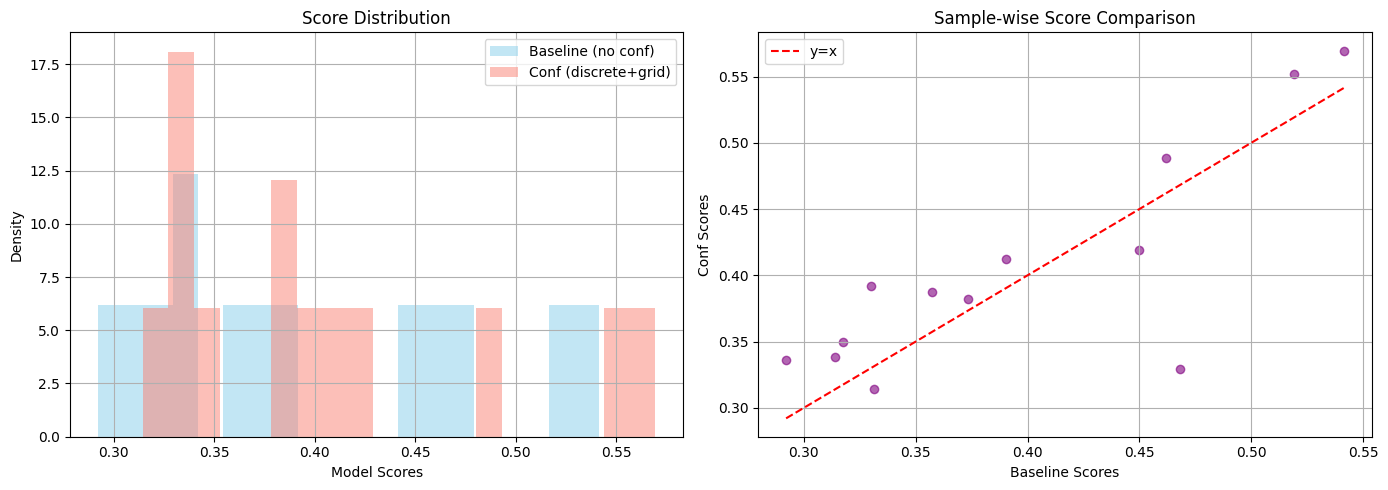

In [25]:
beta = result["regression_coef"][1:]
summary, grid_results = compare_conf_effect(
    model=engine.fce,
    beta=beta,
    indicator_type=engine.fce.indicator_type,
    X=X_eval,
    y_true=y,
    fit_conf_with_grid_search_func=fit_conf_with_grid_search,
    grid_results=result["grid_results"],
    best_param=result["best_param"],
    best_conf=result["best_conf"]
)

In [26]:
df_conf = pd.DataFrame(summary)
print(df_conf)

                  name  spearman   p_value       std        cv     range  \
0    baseline(no_conf)  0.494505  0.085824  0.079925  0.201869  0.249291   
1  conf(discrete+grid)  0.901099  0.000026  0.079887  0.197051  0.255198   

   best_conflict  
0            NaN  
1            0.3  


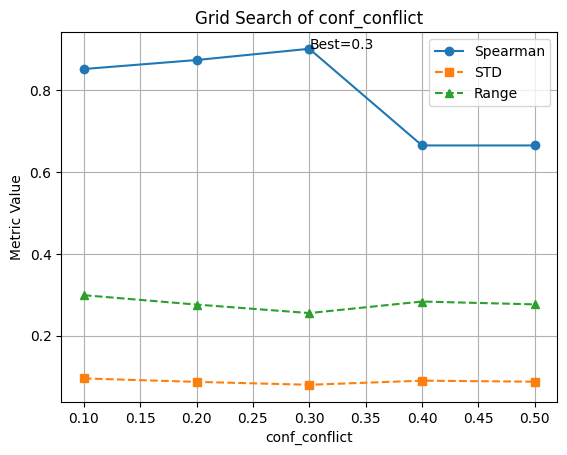

In [27]:
plot_conf_grid_search(result["grid_results"])